In [279]:
import numpy as np
import pandas as pd
import seaborn as sns


import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [280]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [281]:
font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)
plt.rcParams['axes.unicode_minus'] = False

### 1년 단위 FIFA 선수 스탯

In [282]:
df1 = pd.read_csv("./../data/source data/players_stats_2015_2023.csv")
df1

C:\Users\user\AppData\Local\Temp\ipykernel_5044\1737341252.py:1: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("./../data/source data/players_stats_2015_2023.csv")


,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
0,158023,/player/158023/lionel-messi/150002,15,2,2014-09-18,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,...,62+3,62+3,62+3,54+3,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png
1,20801,/player/20801/c-ronaldo-dos-santos-aveiro/150002,15,2,2014-09-18,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,...,63+3,63+3,63+3,57+3,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png
2,9014,/player/9014/arjen-robben/150002,15,2,2014-09-18,A. Robben,Arjen Robben,"RM, LM, RW",90,90,...,64+3,64+3,64+3,55+3,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png
3,41236,/player/41236/zlatan-ibrahimovic/150002,15,2,2014-09-18,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,...,65+3,65+3,61+3,56+3,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png
4,167495,/player/167495/manuel-neuer/150002,15,2,2014-09-18,M. Neuer,Manuel Peter Neuer,GK,90,90,...,40+3,40+3,36+3,36+3,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161578,269011,/player/269011/ziye-zhao/230002,23,2,2022-09-26,Zhao Ziye,赵梓业,RW,46,61,...,32+2,32+2,37+2,36+2,31+2,31+2,31+2,36+2,14+2,https://cdn.sofifa.net/players/269/011/23_120.png
161579,269019,/player/269019/junjie-wu/230002,23,2,2022-09-26,Wu Junjie,吴俊杰,LB,46,58,...,41+2,41+2,43+2,44+2,48+2,48+2,48+2,44+2,15+2,https://cdn.sofifa.net/players/269/019/23_120.png
161580,271093,/player/271093/kailin-barlow/230002,23,2,2022-09-26,K. Barlow,Kailin Barlow,CDM,46,58,...,45+2,45+2,47+2,47+2,46+2,46+2,46+2,47+2,14+2,https://cdn.sofifa.net/players/271/093/23_120.png
161581,271555,/player/271555/gideon-tetteh/230002,23,2,2022-09-26,G. Tetteh,Gideon Tetteh,"RW, LW",46,70,...,30+2,30+2,34+2,32+2,28+2,28+2,28+2,32+2,15+2,https://cdn.sofifa.net/players/271/555/23_120.png


In [283]:
df1["fifa_update_date"] = pd.to_datetime(df1["fifa_update_date"])
df1["fifa_update_date"] = df1["fifa_update_date"].dt.year.astype(int) + 1

In [284]:
df2 = pd.read_csv("./../data/source data/players_stats_24.csv")
df2

,Unnamed: 0,Name,Nation,Club,Position,Age,Overall,Pace,Shooting,Passing,...,Strength,Aggression,Att work rate,Def work rate,Preferred foot,Weak foot,Skill moves,URL,Gender,GK
0,0,Kylian Mbappé,France,Paris SG,ST,24,91,97,90,80,...,77,64,High,Low,Right,4,5,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN
1,1,Erling Haaland,Norway,Manchester City,ST,23,91,89,93,66,...,93,87,High,Medium,Left,3,3,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN
2,2,Kevin De Bruyne,Belgium,Manchester City,CM,32,91,72,88,94,...,74,75,High,Medium,Right,5,4,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN
3,3,Lionel Messi,Argentina,Inter Miami CF,CF,36,90,80,87,90,...,68,44,Low,Low,Left,4,4,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN
4,4,Karim Benzema,France,Al Ittihad,CF,35,90,79,88,83,...,82,63,Medium,Medium,Right,4,4,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15840,15840,Deven Sawhney,India,Odisha FC,LB,21,47,62,26,34,...,57,58,High,Medium,Left,3,2,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN
15841,15841,Wang Tengda,China PR,Dalian Pro,CM,22,47,61,37,45,...,42,51,Medium,Medium,Right,3,2,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN
15842,15842,Wu Yuhang,China PR,Zhejiang Pro,CDM,22,47,56,34,43,...,51,56,Medium,Medium,Right,3,2,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN
15843,15843,Ye Daoxin,China PR,Zhejiang Pro,CB,17,47,58,28,33,...,48,46,Medium,Medium,Right,3,2,https://www.ea.com/games/ea-sports-fc/ratings/...,M,NaN


In [285]:
df2["fifa_update_date"] = 2024

In [286]:
columns = {
    "Name" : "long_name",
    "Age" : "age",
    "ID": "player_id",
    "URL": "player_url",
    "Year": "fifa_update_date",
    "Nation": "nationality_name",
    "Club": "club_name",
    "Overall": "overall",
    "Ball": "skill_ball_control",
    "Dribbling": "skill_dribbling",
    "Composure": "mentality_composure",
    "Reactions": "movement_reactions",
    "Crossing": "attacking_crossing",
    "Acceleration": "movement_acceleration",
    "Stamina": "power_stamina",
    "Strength": "power_strength",
    "Shot": "power_shot_power",
    "Sprint": "movement_sprint_speed",
    "Finishing": "attacking_finishing",
    "Passing": "attacking_short_passing",
    "Defending": "defending_standing_tackle",
    "GK": "gk"
}
df2 = df2.rename(columns=columns)

In [287]:
merged_df = pd.concat([df1, df2], ignore_index=True)
merged_df

,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,Standing,Sliding,Jumping,Aggression,Att work rate,Def work rate,Preferred foot,Weak foot,Skill moves,Gender
0,158023.0,/player/158023/lionel-messi/150002,15.0,2.0,2015,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20801.0,/player/20801/c-ronaldo-dos-santos-aveiro/150002,15.0,2.0,2015,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9014.0,/player/9014/arjen-robben/150002,15.0,2.0,2015,A. Robben,Arjen Robben,"RM, LM, RW",90,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,41236.0,/player/41236/zlatan-ibrahimovic/150002,15.0,2.0,2015,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,167495.0,/player/167495/manuel-neuer/150002,15.0,2.0,2015,M. Neuer,Manuel Peter Neuer,GK,90,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177423,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,2024,NaN,Deven Sawhney,NaN,47,NaN,...,48.0,47.0,45.0,58.0,High,Medium,Left,3.0,2.0,M
177424,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,2024,NaN,Wang Tengda,NaN,47,NaN,...,46.0,44.0,38.0,51.0,Medium,Medium,Right,3.0,2.0,M
177425,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,2024,NaN,Wu Yuhang,NaN,47,NaN,...,45.0,51.0,38.0,56.0,Medium,Medium,Right,3.0,2.0,M
177426,NaN,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,2024,NaN,Ye Daoxin,NaN,47,NaN,...,50.0,46.0,38.0,46.0,Medium,Medium,Right,3.0,2.0,M


In [288]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177428 entries, 0 to 177427
Columns: 137 entries, player_id to Gender
dtypes: float64(71), int64(15), object(51)
memory usage: 185.5+ MB


In [ ]:
columns_keep = [
    "long_name","age","fifa_update_date","nationality_name","overall",
    "skill_ball_control", "skill_dribbling", "mentality_composure", 
    "movement_reactions", "attacking_crossing", "movement_acceleration", 
    "power_stamina", "power_strength", "power_shot_power", 
    "movement_sprint_speed", "attacking_finishing", "gk", 
    "attacking_short_passing", "defending_standing_tackle", "mentality_penalties"
]

columns = {
    "long_name":"name",
    "fifa_update_date": "year",
    "nationality_name": "nation",
    "overall": "current_rating",
    "skill_ball_control": "ball_control",
    "skill_dribbling": "dribbling",
    "mentality_composure": "composure",
    "movement_reactions": "reaction",
    "attacking_crossing": "crossing",
    "movement_acceleration": "acceleration",
    "power_stamina": "stamina",
    "power_strength": "strength",
    "power_shot_power": "shot_power",
    "movement_sprint_speed": "sprint_speed",
    "attacking_finishing": "finishing",
    "attacking_short_passing": "passing",
    "defending_standing_tackle": "defending"
}

filtered_df = merged_df[columns_keep].copy()
filtered_df = filtered_df.rename(columns=columns)
filtered_df.head()

,name,age,year,nation,current_rating,ball_control,dribbling,composure,reaction,crossing,acceleration,stamina,strength,shot_power,sprint_speed,finishing,gk,passing,defending,mentality_penalties
0,Lionel Andrés Messi Cuccittini,27,2015,Argentina,93,96,96,NaN,94,84,96,77,60,80,90,94,15+3,89,21,76.0
1,Cristiano Ronaldo dos Santos Aveiro,29,2015,Portugal,92,92,93,NaN,90,83,91,89,79,94,94,95,16+3,82,31,85.0
2,Arjen Robben,30,2015,Netherlands,90,90,93,NaN,89,80,93,78,65,86,93,85,14+3,86,26,80.0
3,Zlatan Ibrahimović,32,2015,Sweden,90,90,88,NaN,85,76,74,78,93,93,77,91,17+3,84,41,91.0
4,Manuel Peter Neuer,28,2015,Germany,90,31,25,NaN,89,25,58,44,83,42,61,25,87+3,42,25,37.0


In [290]:
filtered_df.info()
filtered_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177428 entries, 0 to 177427
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   name                 177428 non-null  object 
 1   age                  177428 non-null  int64  
 2   year                 177428 non-null  int64  
 3   nation               177428 non-null  object 
 4   current_rating       177428 non-null  int64  
 5   ball_control         177428 non-null  int64  
 6   dribbling            177428 non-null  int64  
 7   composure            144567 non-null  float64
 8   reaction             177428 non-null  int64  
 9   crossing             177428 non-null  int64  
 10  acceleration         177428 non-null  int64  
 11  stamina              177428 non-null  int64  
 12  strength             177428 non-null  int64  
 13  shot_power           177428 non-null  int64  
 14  sprint_speed         177428 non-null  int64  
 15  finishing        

,age,year,current_rating,ball_control,dribbling,composure,reaction,crossing,acceleration,stamina,strength,shot_power,sprint_speed,finishing,passing,defending,mentality_penalties
count,177428.000000,177428.000000,177428.000000,177428.000000,177428.000000,144567.000000,177428.000000,177428.000000,177428.000000,177428.000000,177428.000000,177428.000000,177428.000000,177428.000000,177428.000000,177428.000000,161583.000000
mean,25.187969,2019.560825,65.754627,58.283879,55.316844,57.899825,61.635993,49.659992,64.708383,63.140389,65.187980,56.975556,64.880599,45.705114,58.377511,47.955644,48.668492
std,4.675420,2.810264,7.012080,16.578698,18.616927,12.304172,9.134157,17.995630,14.788256,15.878890,12.607583,15.434333,14.544322,19.281694,14.305182,20.954465,15.652208
min,16.000000,2015.000000,40.000000,5.000000,2.000000,3.000000,20.000000,5.000000,11.000000,10.000000,12.000000,2.000000,11.000000,2.000000,7.000000,2.000000,5.000000
25%,21.000000,2017.000000,61.000000,54.000000,48.000000,50.000000,55.000000,38.000000,57.000000,56.000000,58.000000,48.000000,57.000000,30.000000,53.000000,28.000000,39.000000
50%,25.000000,2020.000000,66.000000,63.000000,61.000000,59.000000,62.000000,54.000000,67.000000,66.000000,66.000000,60.000000,67.000000,49.000000,62.000000,55.000000,50.000000
75%,28.000000,2022.000000,70.000000,69.000000,68.000000,66.000000,68.000000,63.000000,75.000000,74.000000,74.000000,68.000000,75.000000,62.000000,68.000000,66.000000,60.000000
max,54.000000,2024.000000,94.000000,96.000000,97.000000,96.000000,96.000000,95.000000,97.000000,97.000000,98.000000,96.000000,97.000000,96.000000,95.000000,94.000000,96.000000


In [291]:
filtered_df.to_csv("./../data/result data/player_stats_2015_2024.csv")
filtered_df.head()

,name,age,year,nation,current_rating,ball_control,dribbling,composure,reaction,crossing,acceleration,stamina,strength,shot_power,sprint_speed,finishing,gk,passing,defending,mentality_penalties
0,Lionel Andrés Messi Cuccittini,27,2015,Argentina,93,96,96,NaN,94,84,96,77,60,80,90,94,15+3,89,21,76.0
1,Cristiano Ronaldo dos Santos Aveiro,29,2015,Portugal,92,92,93,NaN,90,83,91,89,79,94,94,95,16+3,82,31,85.0
2,Arjen Robben,30,2015,Netherlands,90,90,93,NaN,89,80,93,78,65,86,93,85,14+3,86,26,80.0
3,Zlatan Ibrahimović,32,2015,Sweden,90,90,88,NaN,85,76,74,78,93,93,77,91,17+3,84,41,91.0
4,Manuel Peter Neuer,28,2015,Germany,90,31,25,NaN,89,25,58,44,83,42,61,25,87+3,42,25,37.0


---
### 페널티 예측 ML

In [292]:
columns = ["name","age","nation","mentality_penalties","finishing","shot_power","reaction", "gk", "year"]
penalty_df = filtered_df[columns]

In [293]:
columns = {
    'name':'Player_Name', 
    'age':'Age',
    'nation':'Eng_Nation',
    'mentality_penalties':'Penalty', 
    'finishing':'Finishing', 
    'shot_power':'Shot_Power', 
    'reaction':'Reaction', 
    'year':'Year',
    'gk':'GK',
}

penalty_df = penalty_df.rename(columns=columns)
penalty_df = pd.DataFrame(penalty_df)
penalty_df

,Player_Name,Age,Eng_Nation,Penalty,Finishing,Shot_Power,Reaction,GK,Year
0,Lionel Andrés Messi Cuccittini,27,Argentina,76.0,94,80,94,15+3,2015
1,Cristiano Ronaldo dos Santos Aveiro,29,Portugal,85.0,95,94,90,16+3,2015
2,Arjen Robben,30,Netherlands,80.0,85,86,89,14+3,2015
3,Zlatan Ibrahimović,32,Sweden,91.0,91,93,85,17+3,2015
4,Manuel Peter Neuer,28,Germany,37.0,25,42,89,87+3,2015
...,...,...,...,...,...,...,...,...,...
177423,Deven Sawhney,21,India,NaN,24,33,39,NaN,2024
177424,Wang Tengda,22,China PR,NaN,38,53,48,NaN,2024
177425,Wu Yuhang,22,China PR,NaN,31,51,45,NaN,2024
177426,Ye Daoxin,17,China PR,NaN,25,41,51,NaN,2024


In [294]:
penalty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177428 entries, 0 to 177427
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Player_Name  177428 non-null  object 
 1   Age          177428 non-null  int64  
 2   Eng_Nation   177428 non-null  object 
 3   Penalty      161583 non-null  float64
 4   Finishing    177428 non-null  int64  
 5   Shot_Power   177428 non-null  int64  
 6   Reaction     177428 non-null  int64  
 7   GK           163370 non-null  object 
 8   Year         177428 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 12.2+ MB


In [295]:
penalty_df.describe()

,Age,Penalty,Finishing,Shot_Power,Reaction,Year
count,177428.000000,161583.000000,177428.000000,177428.000000,177428.000000,177428.000000
mean,25.187969,48.668492,45.705114,56.975556,61.635993,2019.560825
std,4.675420,15.652208,19.281694,15.434333,9.134157,2.810264
min,16.000000,5.000000,2.000000,2.000000,20.000000,2015.000000
25%,21.000000,39.000000,30.000000,48.000000,55.000000,2017.000000
50%,25.000000,50.000000,49.000000,60.000000,62.000000,2020.000000
75%,28.000000,60.000000,62.000000,68.000000,68.000000,2022.000000
max,54.000000,96.000000,96.000000,96.000000,96.000000,2024.000000


In [296]:
# 결측치 탐색
penalty_df.isnull().sum()

Player_Name        0
Age                0
Eng_Nation         0
Penalty        15845
Finishing          0
Shot_Power         0
Reaction           0
GK             14058
Year               0
dtype: int64

In [297]:
penalty_df = penalty_df.dropna(subset=["Penalty", "GK"])
penalty_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161583 entries, 0 to 161582
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Player_Name  161583 non-null  object 
 1   Age          161583 non-null  int64  
 2   Eng_Nation   161583 non-null  object 
 3   Penalty      161583 non-null  float64
 4   Finishing    161583 non-null  int64  
 5   Shot_Power   161583 non-null  int64  
 6   Reaction     161583 non-null  int64  
 7   GK           161583 non-null  object 
 8   Year         161583 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 12.3+ MB


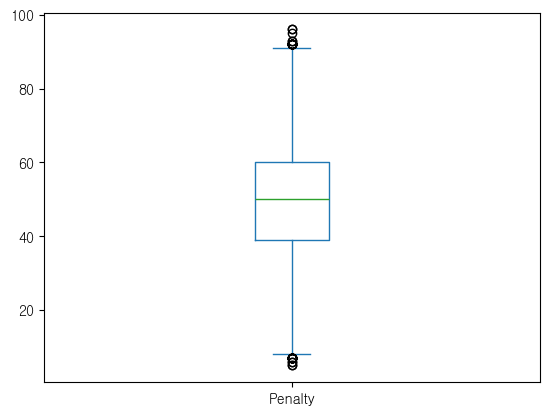

,Player_Name,Age,Eng_Nation,Penalty,Finishing,Shot_Power,Reaction,GK,Year


In [298]:
# 이상치 탐색
penalty_df['Penalty'].plot(kind='box')
plt.show()

penalty_df[penalty_df['Penalty'] < 0]

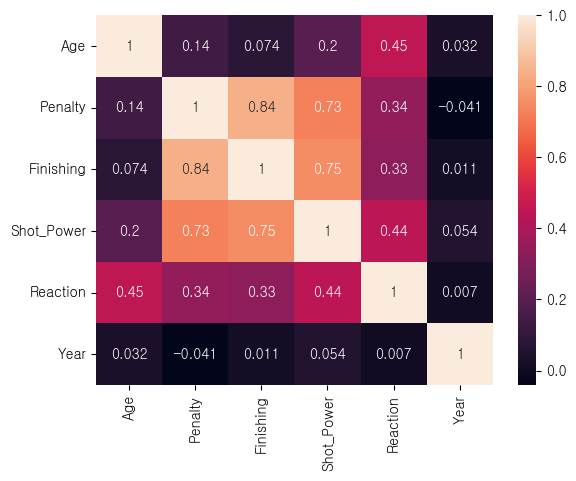

In [299]:
corr_matrix = penalty_df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True)
plt.show()

---

In [300]:
match_df = pd.read_csv("./../data/source data/matches_1930_2022.csv")
match_df = match_df[['Year','home_team','away_team','Score']]
match_df

,Year,home_team,away_team,Score
0,2022,Argentina,France,(4) 3–3 (2)
1,2022,Croatia,Morocco,2–1
2,2022,France,Morocco,2–0
3,2022,Argentina,Croatia,3–0
4,2022,Morocco,Portugal,1–0
...,...,...,...,...
959,1930,Argentina,France,1–0
960,1930,Yugoslavia,Brazil,2–1
961,1930,Romania,Peru,3–1
962,1930,United States,Belgium,3–0


In [301]:
import re

"""
df_match['Score'] 예시: "(4) 3–3 (2)"
반환:  home_penalty_score=4, away_penalty_score=2
"""
def extract_penalty(score):
    pens = re.findall(r'\((\d+)\)', str(score))
    if len(pens) == 2:
        return int(pens[0]), int(pens[1])
    return None, None

match_df[['Home_Penalty_Score', 'Away_Penalty_Score']] = match_df['Score'].apply(
    lambda x: pd.Series(extract_penalty(x))
)
df_match = match_df.dropna(subset=['Home_Penalty_Score', 'Away_Penalty_Score'])
df_match

,Year,home_team,away_team,Score,Home_Penalty_Score,Away_Penalty_Score
0,2022,Argentina,France,(4) 3–3 (2),4.0,2.0
6,2022,Croatia,Brazil,(4) 1–1 (2),4.0,2.0
7,2022,Netherlands,Argentina,(3) 2–2 (4),3.0,4.0
8,2022,Morocco,Spain,(3) 0–0 (0),3.0,0.0
10,2022,Japan,Croatia,(1) 1–1 (3),1.0,3.0
69,2018,Russia,Croatia,(3) 2–2 (4),3.0,4.0
73,2018,Colombia,England,(3) 1–1 (4),3.0,4.0
76,2018,Spain,Russia,(3) 1–1 (4),3.0,4.0
77,2018,Croatia,Denmark,(3) 1–1 (2),3.0,2.0
130,2014,Netherlands,Argentina,(2) 0–0 (4),2.0,4.0


In [302]:
match_df = match_df.drop(columns=['Score'])
match_df = match_df[match_df['Year'] >= 2014].reset_index(drop=True)
match_df

,Year,home_team,away_team,Home_Penalty_Score,Away_Penalty_Score
0,2022,Argentina,France,4.0,2.0
1,2022,Croatia,Morocco,NaN,NaN
2,2022,France,Morocco,NaN,NaN
3,2022,Argentina,Croatia,NaN,NaN
4,2022,Morocco,Portugal,NaN,NaN
...,...,...,...,...,...
187,2014,Côte d'Ivoire,Japan,NaN,NaN
188,2014,Mexico,Cameroon,NaN,NaN
189,2014,Spain,Netherlands,NaN,NaN
190,2014,Chile,Australia,NaN,NaN


---

In [303]:
# merged_df.set_index("Player_Name", inplace=True)

# 피처-라벨 분리
X = penalty_df.drop(["Penalty", "Player_Name", "Eng_Nation", "GK"], axis=1) # Age	Finishing	Shot_Power	Reaction    Year
y = penalty_df["Penalty"]

# 훈련-평가 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# 모델 학습 및 평가
xgb = XGBRegressor(n_estimators=300, learning_rate=0.2, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
print(xgb.score(X_train, y_train)), print(xgb.score(X_test, y_test))

y_pred = xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse}, RMSE: {rmse}, R2: {r2}")

0.7893108999318862
0.7716075123729292
MSE : 55.91561664977926, RMSE: 7.4776745482656075, R2: 0.7716075123729292


In [304]:
penalty_df["Penalty_Prob"] = xgb.predict(X) / 100.0

top5_player = penalty_df.groupby("Eng_Nation").apply(
    lambda x: x.nlargest(7, "Penalty_Prob")
).reset_index(drop=True)

team_success_prob = top5_player.groupby(["Eng_Nation", "Year"])["Penalty_Prob"].mean()
print(team_success_prob)

C:\Users\user\AppData\Local\Temp\ipykernel_5044\740456491.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penalty_df["Penalty_Prob"] = xgb.predict(X) / 100.0


Eng_Nation   Year
Afghanistan  2017    0.545497
             2018    0.514651
             2019    0.515604
             2020    0.518485
             2021    0.605856
                       ...   
Zimbabwe     2017    0.703768
             2018    0.703527
             2019    0.710541
             2020    0.705489
             2023    0.722725
Name: Penalty_Prob, Length: 943, dtype: float32


C:\Users\user\AppData\Local\Temp\ipykernel_5044\740456491.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top5_player = penalty_df.groupby("Eng_Nation").apply(


- softmax
- rand 난수

In [305]:
len(top5_player['Eng_Nation'].unique())

185

In [306]:
team_success_prob = team_success_prob.reset_index()
penalty_df = pd.DataFrame(team_success_prob)
penalty_df

,Eng_Nation,Year,Penalty_Prob
0,Afghanistan,2017,0.545497
1,Afghanistan,2018,0.514651
2,Afghanistan,2019,0.515604
3,Afghanistan,2020,0.518485
4,Afghanistan,2021,0.605856
...,...,...,...
938,Zimbabwe,2017,0.703768
939,Zimbabwe,2018,0.703527
940,Zimbabwe,2019,0.710541
941,Zimbabwe,2020,0.705489


In [307]:
penalty_df.columns

Index(['Eng_Nation', 'Year', 'Penalty_Prob'], dtype='object')

In [308]:
nation_map = {
    'Afghanistan': '아프가니스탄',
    'Albania': '알바니아',
    'Algeria': '알제리',
    'Andorra': '안도라',
    'Angola': '앙골라',
    'Antigua and Barbuda': '앤티가 바부다',
    'Argentina': '아르헨티나',
    'Armenia': '아르메니아',
    'Aruba': '아루바',
    'Australia': '호주',
    'Austria': '오스트리아',
    'Azerbaijan': '아제르바이잔',
    'Bahrain': '바레인',
    'Barbados': '바베이도스',
    'Belarus': '벨라루스',
    'Belgium': '벨기에',
    'Belize': '벨리즈',
    'Benin': '베냉',
    'Bermuda': '버뮤다',
    'Bhutan': '부탄',
    'Bolivia': '볼리비아',
    'Bosnia and Herzegovina': '보스니아 헤르체고비나',
    'Brazil': '브라질',
    'Brunei Darussalam': '브루나이',
    'Bulgaria': '불가리아',
    'Burkina Faso': '부르키나파소',
    'Burundi': '부룬디',
    'Cambodia': '캄보디아',
    'Cameroon': '카메룬',
    'Canada': '캐나다',
    'Cape Verde Islands': '카보베르데',
    'Central African Republic': '중앙아프리카',
    'Chad': '차드',
    'Chile': '칠레',
    'China PR': '중국',
    'Chinese Taipei': '중화 타이베이',
    'Colombia': '콜롬비아',
    'Comoros': '코모로',
    'Congo': '콩고',
    'Congo DR': '콩고민주공화국',
    'Costa Rica': '코스타리카',
    'Croatia': '크로아티아',
    'Cuba': '쿠바',
    'Curacao': '퀴라소',
    'Cyprus': '키프로스',
    'Czech Republic': '체코',
    "Côte d'Ivoire": '코트디부아르',
    'Denmark': '덴마크',
    'Dominican Republic': '도미니카공화국',
    'Ecuador': '에콰도르',
    'Egypt': '이집트',
    'El Salvador': '엘살바도르',
    'England': '잉글랜드',
    'Equatorial Guinea': '적도기니',
    'Eritrea': '에리트레아',
    'Estonia': '에스토니아',
    'Ethiopia': '에티오피아',
    'Faroe Islands': '페로제도',
    'Fiji': '피지',
    'Finland': '핀란드',
    'France': '프랑스',
    'Gabon': '가봉',
    'Gambia': '감비아',
    'Georgia': '조지아',
    'Germany': '독일',
    'Ghana': '가나',
    'Gibraltar': '지브롤터',
    'Greece': '그리스',
    'Grenada': '그레나다',
    'Guam': '괌',
    'Guatemala': '과테말라',
    'Guinea': '기니',
    'Guinea Bissau': '기니비사우',
    'Guyana': '가이아나',
    'Haiti': '아이티',
    'Honduras': '온두라스',
    'Hong Kong': '홍콩',
    'Hungary': '헝가리',
    'Iceland': '아이슬란드',
    'India': '인도',
    'Indonesia': '인도네시아',
    'Iran': '이란',
    'Iraq': '이라크',
    'Israel': '이스라엘',
    'Italy': '이탈리아',
    'Jamaica': '자메이카',
    'Japan': '일본',
    'Jordan': '요르단',
    'Kazakhstan': '카자흐스탄',
    'Kenya': '케냐',
    'Korea DPR': '북한',
    'Korea Republic': '대한민국',
    'Kosovo': '코소보',
    'Kuwait': '쿠웨이트',
    'Kyrgyzstan': '키르기스스탄',
    'Latvia': '라트비아',
    'Lebanon': '레바논',
    'Liberia': '라이베리아',
    'Libya': '리비아',
    'Liechtenstein': '리히텐슈타인',
    'Lithuania': '리투아니아',
    'Luxembourg': '룩셈부르크',
    'Macau': '마카오',
    'Madagascar': '마다가스카르',
    'Malawi': '말라위',
    'Malaysia': '말레이시아',
    'Mali': '말리',
    'Malta': '몰타',
    'Mauritania': '모리타니',
    'Mauritius': '모리셔스',
    'Mexico': '멕시코',
    'Moldova': '몰도바',
    'Montenegro': '세르비아 몬테네그로',
    'Montserrat': '몬트세랫',
    'Morocco': '모로코',
    'Mozambique': '모잠비크',
    'Namibia': '나미비아',
    'Netherlands': '네덜란드',
    'New Caledonia': '뉴칼레도니아',
    'New Zealand': '뉴질랜드',
    'Nicaragua': '니카라과',
    'Niger': '니제르',
    'Nigeria': '나이지리아',
    'North Macedonia': '북마케도니아',
    'Northern Ireland': '북아일랜드',
    'Norway': '노르웨이',
    'Oman': '오만',
    'Palestine': '팔레스타인',
    'Panama': '파나마',
    'Papua New Guinea': '파푸아뉴기니',
    'Paraguay': '파라과이',
    'Peru': '페루',
    'Philippines': '필리핀',
    'Poland': '폴란드',
    'Portugal': '포르투갈',
    'Puerto Rico': '푸에르토리코',
    'Qatar': '카타르',
    'Republic of Ireland': '아일랜드',
    'Romania': '루마니아',
    'Russia': '러시아',
    'Rwanda': '르완다',
    'Saint Kitts and Nevis': '세인트키츠 네비스',
    'Saint Lucia': '세인트루시아',
    'Saint Vincent and the Grenadines': '세인트빈센트 그레나딘',
    'San Marino': '산마리노',
    'Saudi Arabia': '사우디아라비아',
    'Scotland': '스코틀랜드',
    'Senegal': '세네갈',
    'Serbia': '세르비아',
    'Sierra Leone': '시에라리온',
    'Singapore': '싱가포르',
    'Slovakia': '슬로바키아',
    'Slovenia': '슬로베니아',
    'Somalia': '소말리아',
    'South Africa': '남아프리카 공화국',
    'South Sudan': '남수단',
    'Spain': '스페인',
    'Sri Lanka': '스리랑카',
    'Sudan': '수단',
    'Suriname': '수리남',
    'Swaziland': '에스와티니',
    'Sweden': '스웨덴',
    'Switzerland': '스위스',
    'Syria': '시리아',
    'São Tomé e Príncipe': '상투메 프린시페',
    'Tajikistan': '타지키스탄',
    'Tanzania': '탄자니아',
    'Thailand': '태국',
    'Timor-Leste': '동티모르',
    'Togo': '토고',
    'Trinidad and Tobago': '트리니다드 토바고',
    'Tunisia': '튀니지',
    'Turkey': '터키',
    'Turkmenistan': '투르크메니스탄',
    'Uganda': '우간다',
    'Ukraine': '우크라이나',
    'United Arab Emirates': '아랍에미리트',
    'United States': '미국',
    'Uruguay': '우루과이',
    'Uzbekistan': '우즈베키스탄',
    'Venezuela': '베네수엘라',
    'Vietnam': '베트남',
    'Wales': '웨일스',
    'Zambia': '잠비아',
    'Zimbabwe': '짐바브웨'
}

penalty_df['Nation'] = penalty_df['Eng_Nation'].str.strip().replace(nation_map)
print(penalty_df['Nation'].unique())
print(penalty_df['Nation'].isnull().sum())

['아프가니스탄' '알바니아' '알제리' '안도라' '앙골라' '앤티가 바부다' '아르헨티나' '아르메니아' '아루바' '호주'
 '오스트리아' '아제르바이잔' '바레인' '바베이도스' '벨라루스' '벨기에' '벨리즈' '베냉' '버뮤다' '부탄' '볼리비아'
 '보스니아 헤르체고비나' '브라질' '브루나이' '불가리아' '부르키나파소' '부룬디' '캄보디아' '카메룬' '캐나다'
 '카보베르데' '중앙아프리카' '차드' '칠레' '중국' '중화 타이베이' '콜롬비아' '코모로' '콩고' '콩고민주공화국'
 '코스타리카' '크로아티아' '쿠바' '퀴라소' '키프로스' '체코' '코트디부아르' '덴마크' '도미니카공화국' '에콰도르'
 '이집트' '엘살바도르' '잉글랜드' '적도기니' '에리트레아' '에스토니아' '에티오피아' '페로제도' '피지' '핀란드'
 '프랑스' '가봉' '감비아' '조지아' '독일' '가나' '지브롤터' '그리스' '그레나다' '괌' '과테말라' '기니'
 '기니비사우' '가이아나' '아이티' '온두라스' '홍콩' '헝가리' '아이슬란드' '인도' '인도네시아' '이란' '이라크'
 '이스라엘' '이탈리아' '자메이카' '일본' '요르단' '카자흐스탄' '케냐' '북한' '대한민국' '코소보' '쿠웨이트'
 '키르기스스탄' '라트비아' '레바논' '라이베리아' '리비아' '리히텐슈타인' '리투아니아' '룩셈부르크' '마카오'
 '마다가스카르' '말라위' '말레이시아' '말리' '몰타' '모리타니' '모리셔스' '멕시코' '몰도바' '세르비아 몬테네그로'
 '몬트세랫' '모로코' '모잠비크' '나미비아' '네덜란드' '뉴칼레도니아' '뉴질랜드' '니카라과' '니제르' '나이지리아'
 '북마케도니아' '북아일랜드' '노르웨이' '오만' '팔레스타인' '파나마' '파푸아뉴기니' '파라과이' '페루' '필리핀'
 '폴란드' '포르투갈' '푸에르토리코' '카타르' '아일랜드' '루마니아' '러시아' '르완다' '세인트키츠 네비스'
 '세인트루시

In [309]:
penalty_df.to_csv("./../data/result data/penalty_probs.csv")
penalty_df.head()

,Eng_Nation,Year,Penalty_Prob,Nation
0,Afghanistan,2017,0.545497,아프가니스탄
1,Afghanistan,2018,0.514651,아프가니스탄
2,Afghanistan,2019,0.515604,아프가니스탄
3,Afghanistan,2020,0.518485,아프가니스탄
4,Afghanistan,2021,0.605856,아프가니스탄
